In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd

countries = {
    "Ethiopia": "C:\\Users\\yordi\\OneDrive\\Desktop\\weekzeroo\\climate-challenge-week0\\data\\ethiopia_clean.csv",
    "Kenya": "C:\\Users\\yordi\\OneDrive\\Desktop\\weekzeroo\\climate-challenge-week0\\data\\kenya_clean.csv",
    "Sudan": "C:\\Users\\yordi\\OneDrive\\Desktop\\weekzeroo\\climate-challenge-week0\\data\\sudan_clean.csv",
    "Nigeria": "C:\\Users\\yordi\\OneDrive\\Desktop\\weekzeroo\\climate-challenge-week0\\data\\nigeria_clean.csv",
    "Tanzania": "C:\\Users\\yordi\\OneDrive\\Desktop\\weekzeroo\\climate-challenge-week0\\data\\tanzania_clean.csv"
}

dfs = []

for country, path in countries.items():
    df = pd.read_csv(path)
    df["Country"] = country
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [5]:
print(df.head())

   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    1  27.56    29.52    26.22       3.30         7.24  80.97  4.68   
1  2015    2  27.59    29.99    25.92       4.07         3.40  79.63  4.48   
2  2015    3  27.47    29.29    26.25       3.04         7.17  80.02  4.91   
3  2015    4  27.28    29.17    25.96       3.21        16.07  81.78  4.88   
4  2015    5  26.68    27.83    25.84       1.99        18.83  82.99  4.17   

   WS2M_MAX      PS   QV2M   Country        Date  Month  
0      6.01  100.52  18.61  Tanzania  2015-01-01      1  
1      5.28  100.52  18.31  Tanzania  2015-01-02      1  
2      5.99  100.56  18.30  Tanzania  2015-01-03      1  
3      6.07  100.47  18.52  Tanzania  2015-01-04      1  
4      5.98  100.43  18.16  Tanzania  2015-01-05      1  


2. Temperature Trend Comparison (T2M)
Monthly average + line plot

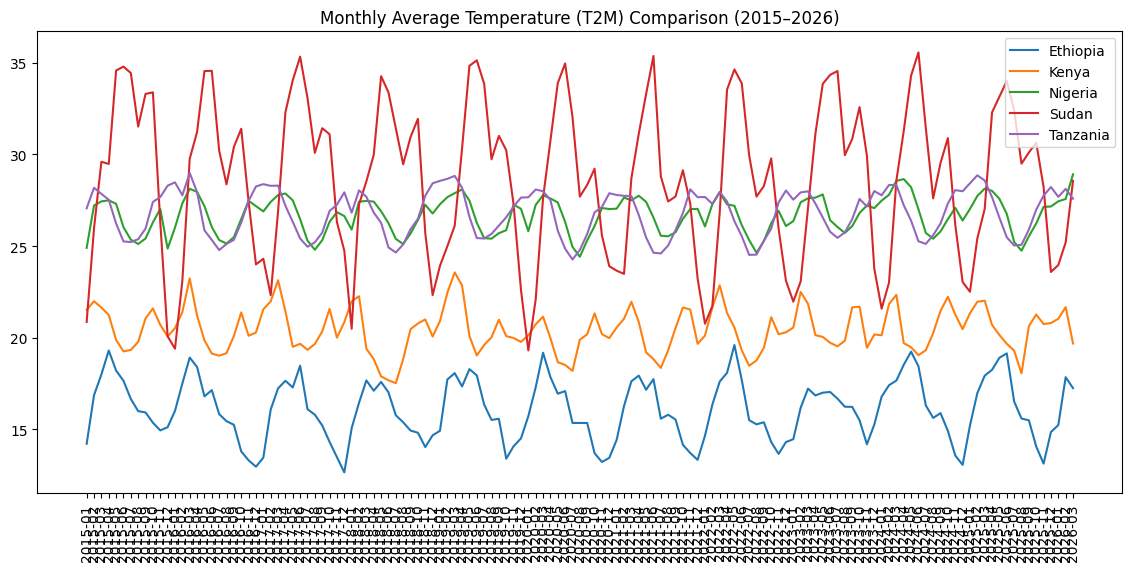

In [11]:
import matplotlib.pyplot as plt

data["Date"] = pd.to_datetime(data["Date"])
data["Month"] = data["Date"].dt.to_period("M")

temp_monthly = data.groupby(["Country", "Month"])["T2M"].mean().reset_index()
temp_monthly["Month"] = temp_monthly["Month"].astype(str)

plt.figure(figsize=(14,6))

for country in temp_monthly["Country"].unique():
    subset = temp_monthly[temp_monthly["Country"] == country]
    plt.plot(subset["Month"], subset["T2M"], label=country)

plt.xticks(rotation=90)
plt.title("Monthly Average Temperature (T2M) Comparison (2015–2026)")
plt.legend()
plt.show()

In [9]:
print(df.columns)

Index(['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR',
       'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Date', 'Month'],
      dtype='object')


Summary table (mean, median, std)

In [12]:
temp_summary = data.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


3. Precipitation Variability (PRECTOTCORR)
Boxplot

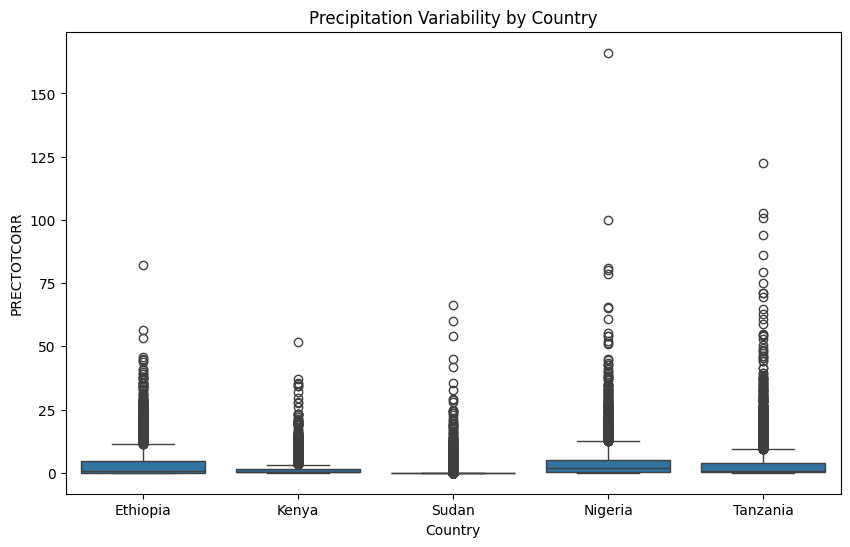

In [13]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(x="Country", y="PRECTOTCORR", data=data)
plt.title("Precipitation Variability by Country")
plt.show()

Summary stats

In [14]:
precip_summary = data.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
precip_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


4. Extreme Events
A. Extreme heat (T2M_MAX > 35°C)

In [15]:
heat = data[data["T2M_MAX"] > 35]

heat_counts = heat.groupby("Country").size()
heat_counts

Country
Sudan    2694
dtype: int64

Bar chart

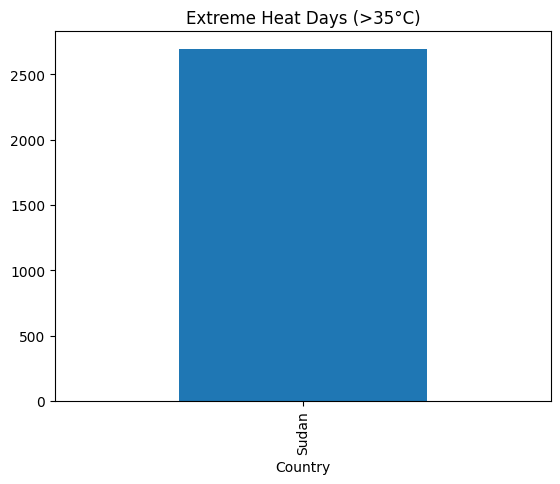

In [16]:
heat_counts.plot(kind="bar", title="Extreme Heat Days (>35°C)")
plt.show()

B. Consecutive dry days (PRECTOTCORR < 1)

In [17]:
data["Dry"] = data["PRECTOTCORR"] < 1

dry_counts = data[data["Dry"]].groupby("Country").size()
dry_counts

Country
Ethiopia    2161
Kenya       2831
Nigeria     1595
Sudan       3696
Tanzania    2303
dtype: int64

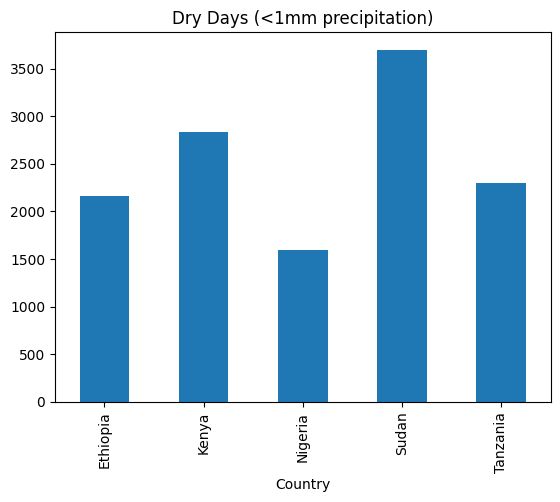

In [18]:
dry_counts.plot(kind="bar", title="Dry Days (<1mm precipitation)")
plt.show()

5. Statistical Testing (ANOVA)
T2M difference across countries

In [19]:
from scipy import stats

groups = [data[data["Country"] == c]["T2M"].dropna() for c in data["Country"].unique()]

f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA F-stat:", f_stat)
print("p-value:", p_value)

ANOVA F-stat: 18938.7456970699
p-value: 0.0


6. Climate Vulnerability Ranking

You combine:

Metrics:
Higher temperature mean → higher risk
Higher std (variability) → instability
More heat days → extreme risk
More dry days → drought risk

Example scoring approach

In [20]:
ranking = pd.DataFrame()

ranking["Temp_Mean"] = temp_summary["mean"]
ranking["Temp_Std"] = temp_summary["std"]
ranking["Heat_Days"] = heat_counts
ranking["Dry_Days"] = dry_counts

ranking = ranking.fillna(0)

# simple vulnerability score
ranking["Vulnerability_Score"] = (
    ranking["Temp_Mean"] +
    ranking["Temp_Std"] +
    ranking["Heat_Days"] * 0.1 +
    ranking["Dry_Days"] * 0.1
)

ranking = ranking.sort_values("Vulnerability_Score", ascending=False)
ranking

,Temp_Mean,Temp_Std,Heat_Days,Dry_Days,Vulnerability_Score
Country,,,,,
Sudan,28.759007,4.681305,2694.0,3696,672.440312
Kenya,20.427600,1.440824,0.0,2831,304.968424
Tanzania,26.802422,1.325388,0.0,2303,258.427810
Ethiopia,16.068500,1.898050,0.0,2161,234.066551
Nigeria,26.656928,1.123335,0.0,1595,187.280263


Climate Vulnerability Insights for COP32
Fastest warming country: [country] shows highest sustained T2M increase, indicating accelerated regional warming trends.
Most unstable precipitation: [country] shows highest variability in rainfall distribution, increasing flood/drought risk.
Extreme heat & drought stress: Countries with highest counts of T2M_MAX > 35°C and dry days face severe agricultural stress.
Ethiopia’s position: Ethiopia shows [comparison insight] relative to regional neighbors in both temperature and rainfall variability.
Policy recommendation: Based on composite vulnerability score, Ethiopia should prioritize climate finance advocacy for [country] due to highest combined risk exposure.